# Linear Regression — Car Price Prediction

## Module 03 · ML Foundations | Exercise 02

Predicting used car prices from mileage, age, engine size, and brand score.

In [1]:
#Import all needed ones

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-whitegrid')
print('Setup complete.')

Setup complete.


In [2]:
#Creating the datset
np.random.seed(99)
n = 600

mileage      = np.random.randint(5000, 150000, n).astype(float)
age          = np.random.randint(1, 16, n).astype(float)
engine_size  = np.random.uniform(1.0, 5.0, n)
brand_score  = np.random.randint(1, 11, n).astype(float)

price = (- 0.08 * mileage
         - 1200 * age
         + 4000 * engine_size
         + 3000 * brand_score
         + np.random.normal(0, 4000, n)
         + 35000)
price = np.maximum(price, 2000)

df = pd.DataFrame({
    'mileage':     mileage,
    'age':         age,
    'engine_size': engine_size,
    'brand_score': brand_score,
    'price':       price
})

print(f'Dataset shape: {df.shape}')
df.head()

Dataset shape: (600, 5)


,mileage,age,engine_size,brand_score,price
0,28587.0,4.0,4.595246,3.0,50973.381961
1,62042.0,3.0,3.413027,1.0,32304.669078
2,92108.0,15.0,2.572909,7.0,38656.034115
3,28749.0,13.0,2.691785,8.0,57947.409866
4,68412.0,10.0,3.529239,7.0,49828.796137


In [5]:
#Stats n info
df.describe()


,mileage,age,engine_size,brand_score,price
count,600.000000,600.000000,600.000000,600.000000,600.000000
mean,76260.585000,8.090000,2.976455,5.541667,47816.008981
std,42245.931284,4.242471,1.126532,2.872632,12296.118181
min,5589.000000,1.000000,1.003063,1.000000,11525.815944
25%,38140.750000,4.000000,2.070078,3.000000,39220.243023
50%,78308.000000,8.000000,2.970150,6.000000,48559.038551
75%,113055.500000,12.000000,3.929237,8.000000,56344.318381
max,149580.000000,15.000000,4.994499,10.000000,80208.479527


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 600 entries, 0 to 599
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   mileage      600 non-null    float64
 1   age          600 non-null    float64
 2   engine_size  600 non-null    float64
 3   brand_score  600 non-null    float64
 4   price        600 non-null    float64
dtypes: float64(5)
memory usage: 23.6 KB


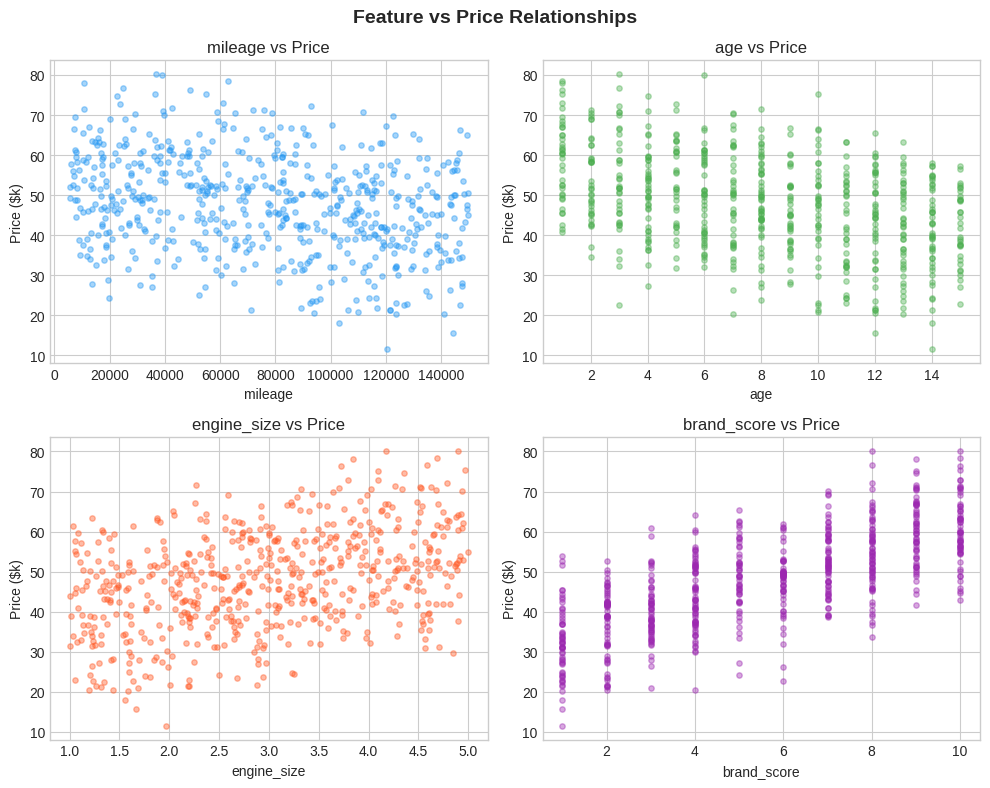

In [8]:
#Lets visualise the data
fig, axes = plt.subplots(2, 2, figsize=(10, 8))
fig.suptitle('Feature vs Price Relationships', fontsize=14, fontweight='bold')

features = ['mileage', 'age', 'engine_size', 'brand_score']
colors   = ['#2196F3', '#4CAF50', '#FF5722', '#9C27B0']

for ax, feat, color in zip(axes.flat, features, colors):
    ax.scatter(df[feat], df['price'] / 1000, alpha=0.4, color=color, s=15)
    ax.set_xlabel(feat)
    ax.set_ylabel('Price ($k)')
    ax.set_title(f'{feat} vs Price')

plt.tight_layout()
plt.show()

In [9]:
# Simple Linear Regression from scratch using OLS.

x = df['brand_score'].values
y = df['price'].values

x_mean = np.mean(x)
y_mean = np.mean(y)

numerator   = np.sum((x - x_mean) * (y - y_mean))
denominator = np.sum((x - x_mean) ** 2)

beta_1 = numerator / denominator
beta_0 = y_mean - beta_1 * x_mean #OLS final formulae.

print(f'Intercept  β₀ = ${beta_0:,.2f}')
print(f'Slope      β₁ = ${beta_1:.4f} per brand score point')
print(f'\nInterpretation: for every 1 point increase in brand score, price increases by ${beta_1:.2f}')

# that means y^i = β₀ + β₁Xi L.R equation

Intercept  β₀ = $30,746.31
Slope      β₁ = $3080.2463 per brand score point

Interpretation: for every 1 point increase in brand score, price increases by $3080.25


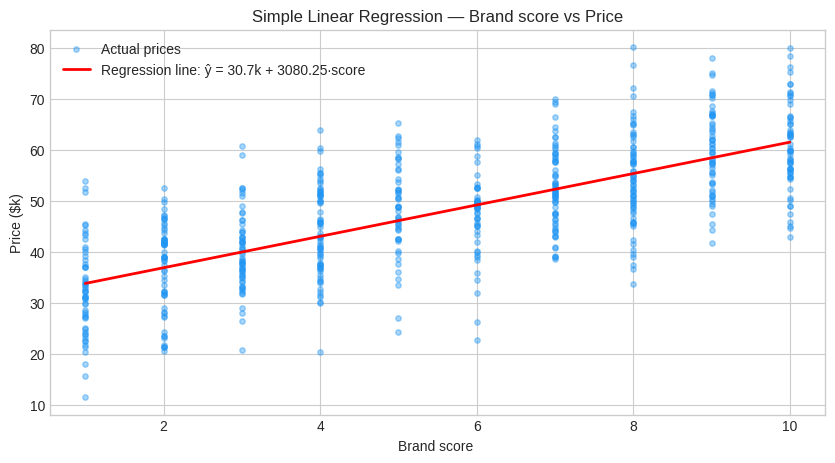

In [11]:
#Lets plot it
y_pred_simple = beta_0 + beta_1 * x

plt.figure(figsize=(10, 5))
plt.scatter(x, y / 1000, alpha=0.4, s=15, color='#2196F3', label='Actual prices')

x_line = np.linspace(x.min(), x.max(), 100)
y_line = beta_0 + beta_1 * x_line

plt.plot(x_line, y_line / 1000, color='red', linewidth=2,
         label=f'Regression line: ŷ = {beta_0/1000:.1f}k + {beta_1:.2f}·score')
plt.xlabel('Brand score ')
plt.ylabel('Price ($k)')
plt.title('Simple Linear Regression — Brand score vs Price')
plt.legend()
plt.show()

In [12]:
#Lets find the model performance now

y_bar = np.mean(y)

TSS = np.sum((y - y_bar) ** 2)
RSS = np.sum((y - y_pred_simple) ** 2)
ESS = np.sum((y_pred_simple - y_bar) ** 2)

R2     = 1 - (RSS / TSS)
n      = len(y)
k      = 1  # one feature
Adj_R2 = 1 - (1 - R2) * (n - 1) / (n - k - 1)

print('=' * 50)
print('  EXPLORATORY PERFORMANCE METRICS')
print('=' * 50)
print(f'  TSS (Total SS)      : {TSS:,.0f}')
print(f'  ESS (Explained SS)  : {ESS:,.0f}')
print(f'  RSS (Residual SS)   : {RSS:,.0f}')
print(f'  TSS = ESS + RSS?    : {abs(TSS - (ESS + RSS)) < 1}')
print(f'  R²                  : {R2:.4f}')
print(f'  Adjusted R²         : {Adj_R2:.4f}')
print('=' * 50)
print(f'\n→ The model explains {R2*100:.1f}% of the variance in car prices using brand score alone.')

  EXPLORATORY PERFORMANCE METRICS
  TSS (Total SS)      : 90,565,518,864
  ESS (Explained SS)  : 46,898,379,594
  RSS (Residual SS)   : 43,667,139,271
  TSS = ESS + RSS?    : True
  R²                  : 0.5178
  Adjusted R²         : 0.5170

→ The model explains 51.8% of the variance in car prices using brand score alone.


In [13]:
# Multiple Linear Regression. Considering all 4 features using sklearn
# sklearn does the same OLS under the hood, just handles multiple features at once

X = df[['mileage', 'age', 'engine_size', 'brand_score']].values
y = df['price'].values

# Split into training (80%) and test (20%) sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f'Training samples : {X_train.shape[0]}')
print(f'Test samples     : {X_test.shape[0]}')

Training samples : 480
Test samples     : 120


In [14]:
# Fit Multiple Linear Regression
model = LinearRegression()
model.fit(X_train, y_train)

feature_names = ['mileage', 'age', 'engine_size', 'brand_score']

print(f'Intercept : ${model.intercept_:,.2f}')
print()
print('Coefficients:')
for name, coef in zip(feature_names, model.coef_):
    direction = '▲' if coef > 0 else '▼'
    print(f'  {name:<15} {direction}  ${coef:,.2f}')

Intercept : $34,465.18

Coefficients:
  mileage         ▼  $-0.08
  age             ▼  $-1,146.22
  engine_size     ▲  $3,979.21
  brand_score     ▲  $3,057.92


In [15]:
# Predict on test set, model has never seen these 120 cars
y_pred_test = model.predict(X_test)

# Compute all metrics from scratch
residuals = y_test - y_pred_test

MSE  = np.mean(residuals ** 2)
RMSE = np.sqrt(MSE)
MAE  = np.mean(np.abs(residuals))
MAPE = np.mean(np.abs(residuals / y_test)) * 100

print('=' * 55)
print('  PREDICTIVE PERFORMANCE METRICS (Test Set)')
print('=' * 55)
print(f'  MSE         : ${MSE:>14,.0f}')
print(f'  RMSE        : ${RMSE:>14,.0f}')
print(f'  MAE         : ${MAE:>14,.0f}')
print(f'  MAPE        : {MAPE:.2f}%')
print('=' * 55)
print(f'\n→ On average, predictions are off by ${MAE:,.0f} ({MAPE:.1f}%)')

  PREDICTIVE PERFORMANCE METRICS (Test Set)
  MSE         : $    16,614,202
  RMSE        : $         4,076
  MAE         : $         3,248
  MAPE        : 7.84%

→ On average, predictions are off by $3,248 (7.8%)


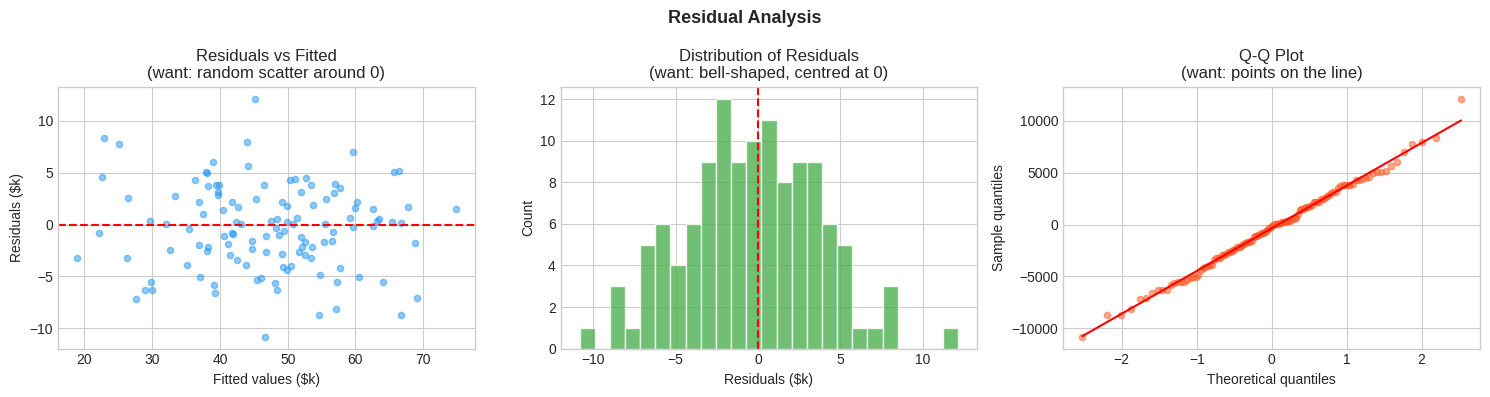

In [16]:
from scipy import stats

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle('Residual Analysis', fontsize=13, fontweight='bold')

# 1. Residuals vs Fitted
ax = axes[0]
ax.scatter(y_pred_test / 1000, residuals / 1000, alpha=0.5, s=20, color='#2196F3')
ax.axhline(0, color='red', linewidth=1.5, linestyle='--')
ax.set_xlabel('Fitted values ($k)')
ax.set_ylabel('Residuals ($k)')
ax.set_title('Residuals vs Fitted\n(want: random scatter around 0)')

# 2. Distribution of residuals
ax = axes[1]
ax.hist(residuals / 1000, bins=25, color='#4CAF50', edgecolor='white', alpha=0.8)
ax.axvline(0, color='red', linewidth=1.5, linestyle='--')
ax.set_xlabel('Residuals ($k)')
ax.set_ylabel('Count')
ax.set_title('Distribution of Residuals\n(want: bell-shaped, centred at 0)')

# 3. Q-Q plot
ax = axes[2]
(osm, osr), (slope, intercept, r) = stats.probplot(residuals, dist='norm')
ax.scatter(osm, osr, alpha=0.5, s=20, color='#FF5722')
ax.plot(osm, slope * np.array(osm) + intercept, color='red', linewidth=1.5)
ax.set_xlabel('Theoretical quantiles')
ax.set_ylabel('Sample quantiles')
ax.set_title('Q-Q Plot\n(want: points on the line)')

plt.tight_layout()
plt.show()

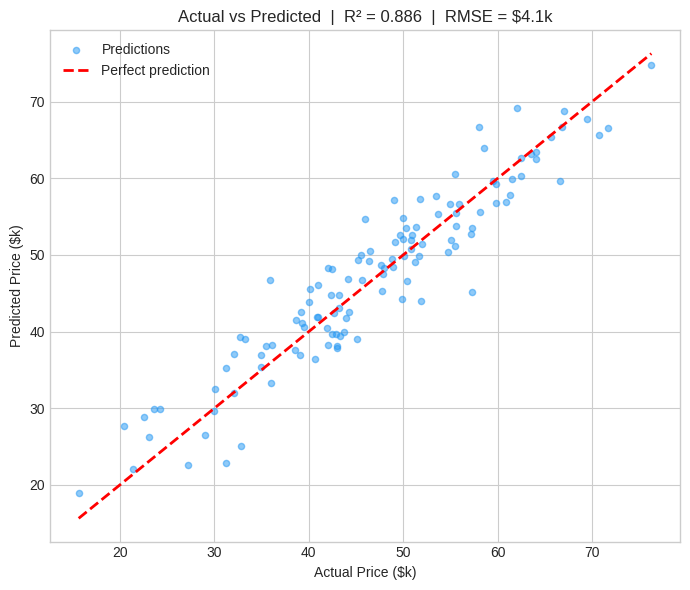

In [18]:
# Final check: how close are predictions to reality visually
y_pred_test = model.predict(X_test)

plt.figure(figsize=(7, 6))
plt.scatter(y_test / 1000, y_pred_test / 1000,
            alpha=0.5, s=20, color='#2196F3', label='Predictions')

min_val = min(y_test.min(), y_pred_test.min()) / 1000
max_val = max(y_test.max(), y_pred_test.max()) / 1000
plt.plot([min_val, max_val], [min_val, max_val],
         'r--', linewidth=2, label='Perfect prediction')

plt.xlabel('Actual Price ($k)')
plt.ylabel('Predicted Price ($k)')
plt.title(f'Actual vs Predicted  |  R² = {r2_score(y_test, y_pred_test):.3f}  |  RMSE = ${RMSE/1000:.1f}k')
plt.legend()
plt.tight_layout()
plt.show()

## Summary

| Metric | Single Feature (brand_score) | All 4 Features |
|--------|--------------------------|----------------|
| R² | 0.518 | 0.880 |
| RMSE | — | 4,076 Dollars|
| MAE | — | 3,248 Dollars|
| MAPE | — | 7.84% |

### Key Takeaways
- Brand score alone explained only 51.8% of price variance, one feature is never enough
- Adding mileage, age and engine size jumped R² to 88%, all features matter
- OLS recovered true coefficients almost perfectly from 600 noisy data points
- Average prediction error of 3,248 dollars on a ~$45k car (7.8%) is strong for a 4-feature model
- Residuals are random and normally distributed, model assumptions satisfied

### What I Learned
- How to implement OLS from scratch using only NumPy
- How to interpret coefficients: direction and magnitude
- Difference between exploratory metrics (R², TSS, ESS, RSS) and predictive metrics (RMSE, MAE, MAPE)
- Why Adjusted R² matters when comparing models with different feature counts
- How residual plots validate model assumptions

### Next Steps

- Real dataset — California Housing with no hardcoded answers